In [38]:
import convolutions
import skimage.io as skio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import cv2

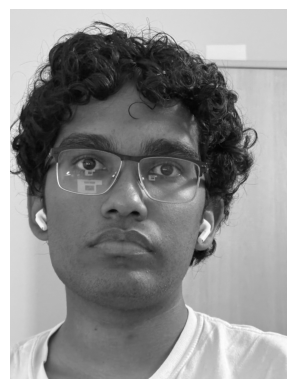

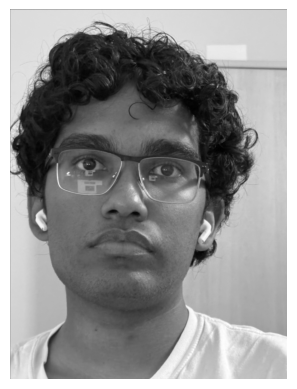

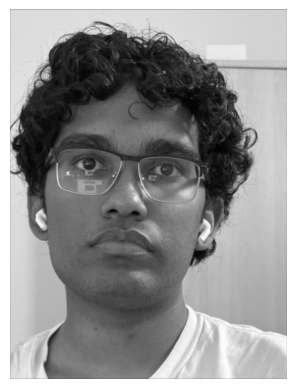

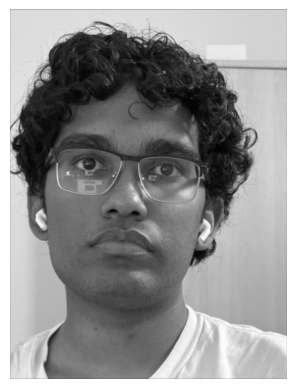

In [ ]:
me_img = skio.imread("media/me_far.jpeg", as_gray = True)
me_img = np.rot90(me_img, k=-1)
box = np.ones((9,9)) / 81

conv4 = convolutions.convolution4(me_img, box, mode = "same")
conv2 = convolutions.convolution(me_img, box, mode = "same")
sci_py_conv = convolve2d(me_img, box, mode="same")


plt.imshow(me_img, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv4, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv2, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_conv, cmap="gray"); plt.axis("off"); plt.show()

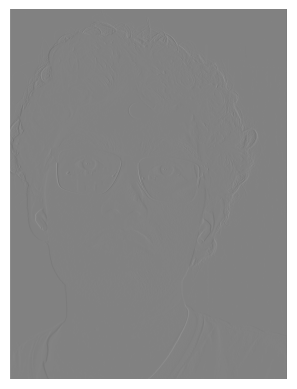

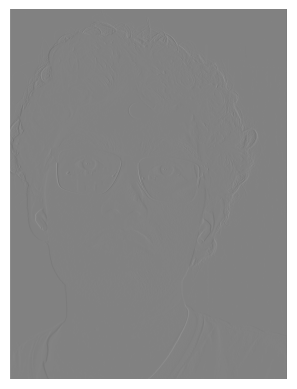

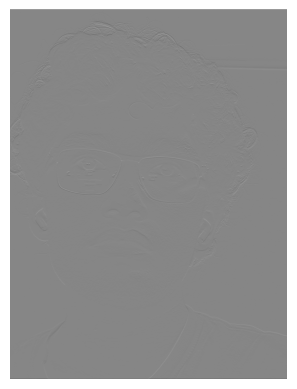

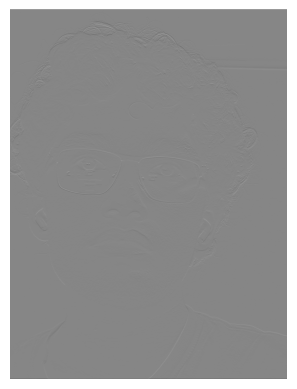

In [ ]:
Dx = np.array([[1, 0, -1]])
Dy = np.array([[1],[0],[-1]])
conv2x = convolutions.convolution(me_img, Dx, mode = "same")
sci_py_convx = convolve2d(me_img, Dx, mode="same")
conv2y = convolutions.convolution(me_img, Dy, mode = "same")
sci_py_convy = convolve2d(me_img, Dy, mode="same")

plt.imshow(conv2x, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_convx, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(conv2y, cmap="gray"); plt.axis("off"); plt.show()
plt.imshow(sci_py_convy, cmap="gray"); plt.axis("off"); plt.show()

Text(0.5, 1.0, 'Dy')

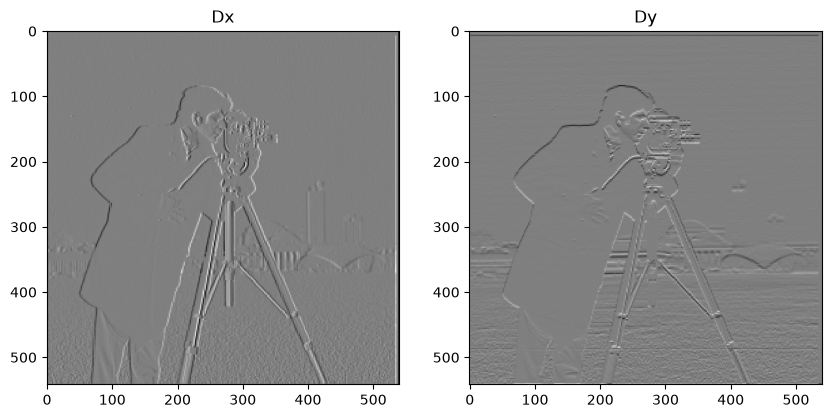

In [13]:
cameraman_img = skio.imread("media/cameraman.png", as_gray=True)
conv2x = convolutions.convolution(cameraman_img, Dx, mode = "same")
conv2y = convolutions.convolution(cameraman_img, Dy, mode = "same")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(conv2x, cmap="gray"); ax[0].set_title("Dx")
ax[1].imshow(conv2y, cmap="gray"); ax[1].set_title("Dy")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

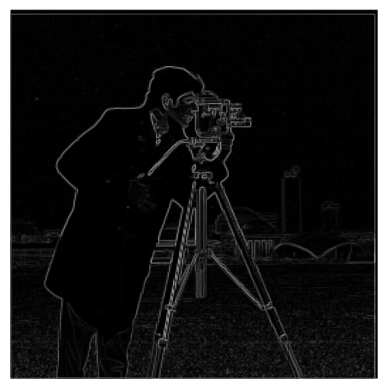

In [16]:
#Gradient magnitude!
cam_gradmag = np.sqrt(conv2x**2 + conv2y**2)
plt.imshow(cam_gradmag, cmap="gray"); plt.axis("off")

(array([1.39472e+05, 5.09840e+04, 1.75030e+04, 1.25710e+04, 9.76500e+03,
        7.94600e+03, 6.87600e+03, 5.63500e+03, 4.81300e+03, 3.83800e+03,
        3.00600e+03, 2.72100e+03, 2.08300e+03, 1.98200e+03, 1.42800e+03,
        1.28800e+03, 1.21200e+03, 9.84000e+02, 1.07000e+03, 9.84000e+02,
        8.42000e+02, 8.56000e+02, 7.14000e+02, 8.28000e+02, 8.64000e+02,
        6.97000e+02, 8.03000e+02, 6.52000e+02, 7.66000e+02, 7.33000e+02,
        6.64000e+02, 6.18000e+02, 5.37000e+02, 5.04000e+02, 4.93000e+02,
        4.24000e+02, 4.66000e+02, 4.24000e+02, 3.57000e+02, 4.12000e+02,
        2.95000e+02, 2.97000e+02, 2.91000e+02, 2.90000e+02, 3.34000e+02,
        2.13000e+02, 1.29000e+02, 1.17000e+02, 9.50000e+01, 1.12000e+02,
        7.90000e+01, 8.70000e+01, 6.60000e+01, 5.20000e+01, 5.20000e+01,
        4.40000e+01, 5.10000e+01, 3.50000e+01, 2.70000e+01, 2.10000e+01,
        1.50000e+01, 9.00000e+00, 6.00000e+00, 1.80000e+01, 1.00000e+01,
        4.00000e+00, 1.00000e+01, 6.00000e+00, 0.00

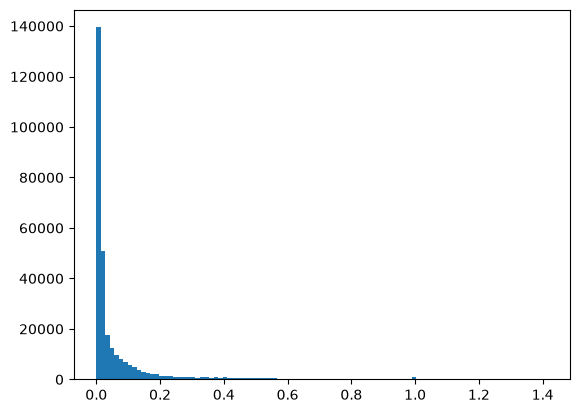

In [22]:
plt.hist(cam_gradmag.ravel(), bins=100)

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

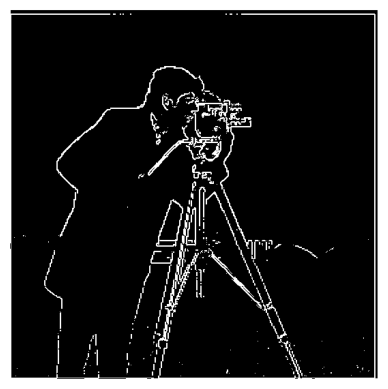

In [34]:
t=0.30
edges = cam_gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

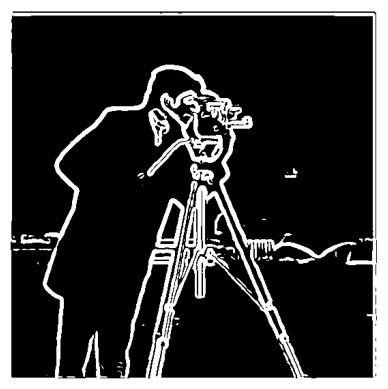

In [49]:
sigma = 2
ksize=int(6*sigma + 1)
g1d=cv2.getGaussianKernel(ksize,sigma)
G=g1d@g1d.T
blur=convolve2d(cameraman_img,G,mode="same")
dx=convolve2d(blur,Dx,mode="same")
dy=convolve2d(blur,Dy,mode="same")
gradmag=np.sqrt(dx**2+dy**2)

t=0.07
edges=gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")

(np.float64(-0.5), np.float64(539.5), np.float64(541.5), np.float64(-0.5))

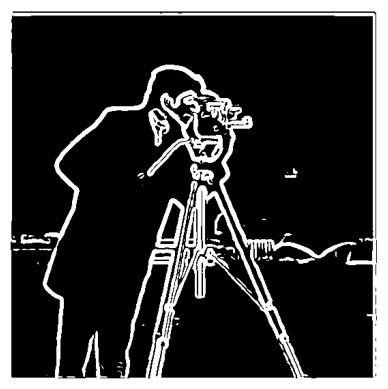

In [51]:
DGx = convolve2d(G, Dx, mode="full")
DGy = convolve2d(G, Dy, mode="full")
dx2=convolve2d(cameraman_img,DGx,mode="same")
dy2=convolve2d(cameraman_img,DGy,mode="same")
gradmag=np.sqrt(dx**2+dy**2)

t=0.07
edges=gradmag>t
plt.imshow(edges,cmap="gray");plt.axis("off")